# Testing Linear Model for Non-Linear Binary Classification

**Objective:** 
To investigates why linear models fail on non-linearly separable data 
To test whether adding depth and width to a linear model can improve accuracy.

## Classification Models
[Classification](https://www.geeksforgeeks.org/machine-learning/getting-started-with-classification/) is a supervised machine learning technique used to predict labels or categories from input data. It assigns each data point to a predefined class based on learned patterns.

Here are major uses for classification models:
* Predict categories: Determines the class of new data points.
* Uses labeled data: Trained on datasets where the correct class is known.
* Common examples: Spam vs non spam emails, diseased vs. healthy patients.

### Types of Classification
Classification in machine learning involves sorting data into categories based on their features or characteristics. The type of classification problem depends on how many classes exist and how the categories are structured.
* [Binary Classification](https://www.geeksforgeeks.org/machine-learning/getting-started-with-classification/)
* [Multiclass Classification](https://www.geeksforgeeks.org/machine-learning/multiclass-classification-using-scikit-learn/)
* [Multi Label Classification](https://www.geeksforgeeks.org/machine-learning/an-introduction-to-multilabel-classification/)


## About the Dataset

The [`Binary Classification Moons`](./Resources/binary_classification_moons.csv) dataset contains two features ($X_1$, $X_2$) and a binary `label`. The data forms two interleaving crescent shapes that resemble cresent moon.

This complex structure of the dataset makes it difficult to train a linear model especially given how linear models already struggled at regression with non-linear datasets.



**Dataset :** [Binary Classification Moons](./Resources/binary_classification_moons.csv)

### **Visualizing the dataset**

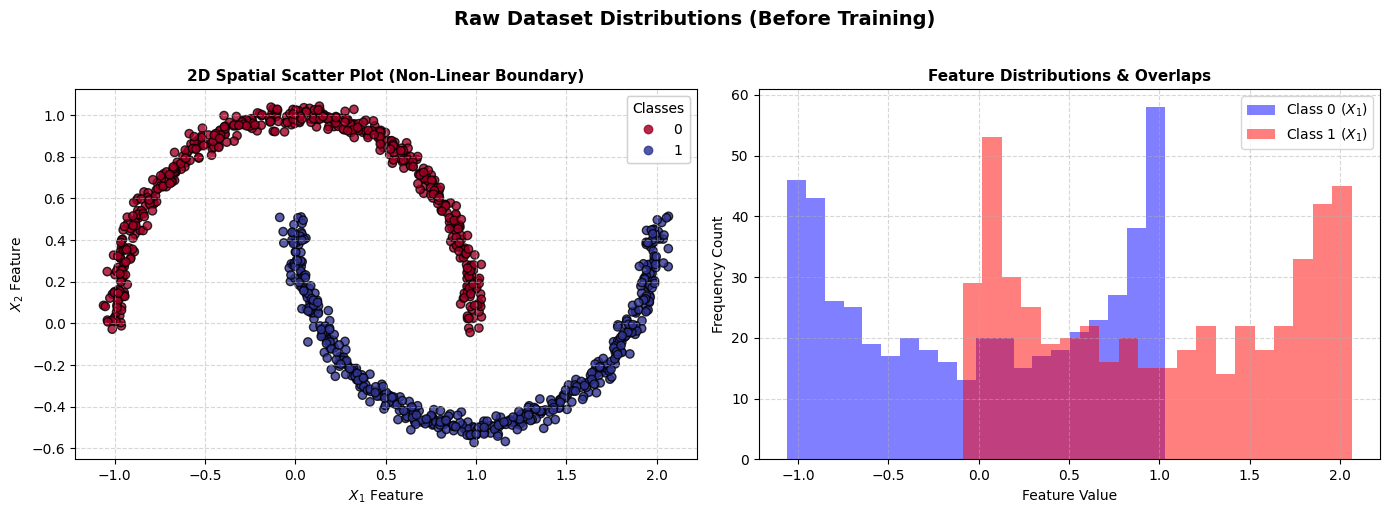

In [349]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load dataset
df = pd.read_csv('./Resources/binary_classification_moons.csv')

# Initialize a 1x2 subplot figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter Plot - Visualizing the "Moons" structure
scatter = axes[0].scatter(
    x=df['X1'], 
    y=df['X2'], 
    c=df['label'], 
    cmap=plt.cm.RdYlBu, 
    edgecolor='k', 
    alpha=0.8
)
axes[0].set_title("2D Spatial Scatter Plot (Non-Linear Boundary)", fontsize=11, fontweight='semibold')
axes[0].set_xlabel("$X_1$ Feature")
axes[0].set_ylabel("$X_2$ Feature")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Add a legend for the classes
legend = axes[0].legend(*scatter.legend_elements(), title="Classes", loc="upper right")
axes[0].add_artist(legend)

# 2. Histogram/Density Plot - Visualizing feature spreads
axes[1].hist(df[df['label'] == 0]['X1'], bins=20, alpha=0.5, label='Class 0 ($X_1$)', color='blue')
axes[1].hist(df[df['label'] == 1]['X1'], bins=20, alpha=0.5, label='Class 1 ($X_1$)', color='red')
axes[1].set_title("Feature Distributions & Overlaps", fontsize=11, fontweight='semibold')
axes[1].set_xlabel("Feature Value")
axes[1].set_ylabel("Frequency Count")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle='--', alpha=0.5)

# Layout adjustments matching your template
plt.suptitle("Raw Dataset Distributions (Before Training)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Understanding the dataset:
The scatter plot shows that the data is organized into two intertwined semi-circular patterns. This shape closely resembles the crescent phase of the moon and therefore this distribution is called crescent moons dataset. 

The histogram for $X_1$ shows significant overlapping distributions between Class 0 and Class 1. This means that $X_1$ by itself is a weak individual predictor. Likewise $X_2$ by itself would also be a weak individual predictor.
Therefore, the two features must be used together in oreder to produce a reliable model.

## **Data Loading and Preparation**

- Features ($X_1$, $X_2$) and labels are converted to `float` tensors for PyTorch. The labels are also reshaped to `(N, 1)`. Data is split in the ratio of 80 to 20 for training and testing the model.

- [*BCEWithLogitsLoss*](https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCEWithLogitsLoss.html) is used instead of [*BCELoss*](https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCELoss.html) because it combines sigmoid + binary cross-entropy. The model outputs raw logits and the loss function applies sigmoid internally. Basically this automates the process while making it more reliable. 

In [350]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup device and load data safely (.copy() prevents the UserWarning)
device = "cuda" if torch.cuda.is_available() else "cpu"
df = pd.read_csv('./Resources/binary_classification_moons.csv')
X = torch.from_numpy(df[['X1', 'X2']].values.copy()).type(torch.float)
y = torch.from_numpy(df['label'].values.copy()).type(torch.float).unsqueeze(1)

# 2. Split into Train/Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# 3. Define the Linear Regression NN Architecture
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=2, out_features=1, bias=True)

    def forward(self, x):
        return self.linear(x)

# 4. Instantiate model, loss function, and optimizer
model_linear = LinearRegressionNN().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_linear.parameters(), lr=0.1)

## **Training loop and model evaluation**

Starting Training for LinearRegressionNN...
--------------------------------------------------
Epoch:   0 | Train Loss: 0.69711, Acc: 47.00% | Test Loss: 0.70987, Test Acc: 45.50%
Epoch:  20 | Train Loss: 0.58079, Acc: 62.50% | Test Loss: 0.60282, Test Acc: 57.00%
Epoch:  40 | Train Loss: 0.51060, Acc: 70.75% | Test Loss: 0.53662, Test Acc: 64.00%
Epoch:  60 | Train Loss: 0.46484, Acc: 74.88% | Test Loss: 0.49240, Test Acc: 68.00%
Epoch:  80 | Train Loss: 0.43289, Acc: 77.25% | Test Loss: 0.46082, Test Acc: 71.00%
Epoch: 100 | Train Loss: 0.40929, Acc: 78.88% | Test Loss: 0.43700, Test Acc: 73.50%


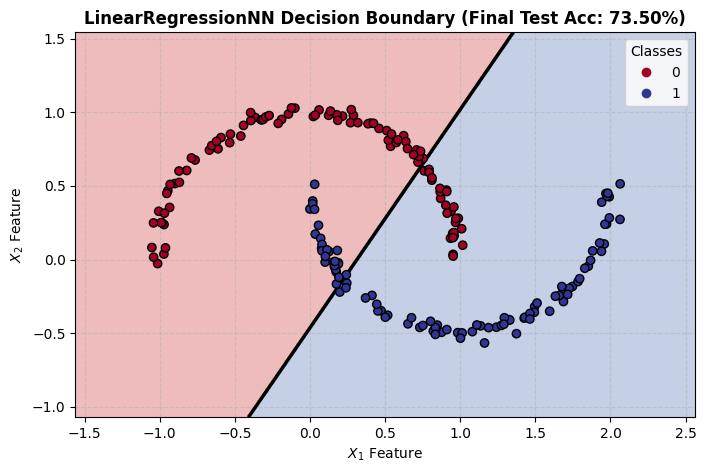

In [351]:
torch.manual_seed(42)
epochs = 100

print("Starting Training for LinearRegressionNN...\n" + "-"*50)
for epoch in range(epochs + 1):
    model_linear.train()
    y_logits = model_linear(X_train)
    loss = loss_fn(y_logits, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model_linear.eval()
        with torch.inference_mode():
            test_logits = model_linear(X_test)
            test_loss = loss_fn(test_logits, y_test)
            train_preds = torch.round(torch.sigmoid(y_logits))
            test_preds = torch.round(torch.sigmoid(test_logits))
            train_acc = (train_preds == y_train).sum().item() / len(y_train) * 100
            test_acc = (test_preds == y_test).sum().item() / len(y_test) * 100
            
        print(f"Epoch: {epoch:3d} | Train Loss: {loss.item():.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss.item():.5f}, Test Acc: {test_acc:.2f}%")

# --- PLOTTING CODE ---
model_linear.eval()
with torch.inference_mode():
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).type(torch.float).to(device)
    
    # Get continuous prediction values (logits) to find the exact 0.0 threshold
    grid_logits = model_linear(grid).reshape(xx.shape).cpu().numpy()
    grid_preds = torch.round(torch.sigmoid(torch.from_numpy(grid_logits))).numpy()

# Generate Plot
plt.figure(figsize=(8, 5))
# Shaded background
plt.contourf(xx, yy, grid_preds, cmap=plt.cm.RdYlBu, alpha=0.3)

# NEW: Explicitly drawing the decision boundary line at threshold 0
plt.contour(xx, yy, grid_logits, levels=[0], colors='black', linewidths=2.5, linestyles='solid')

# Scatter data points
scatter = plt.scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu().squeeze(), cmap=plt.cm.RdYlBu, edgecolors='k', zorder=3)
plt.title(f"LinearRegressionNN Decision Boundary (Final Test Acc: {test_acc:.2f}%)", fontsize=12, fontweight='bold')
plt.xlabel("$X_1$ Feature")
plt.ylabel("$X_2$ Feature")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Understanding the graph:
The prediction decision graph here shows the two cresent moons ie, blue and red moons. The region is coloured based on model prediction. The red region of the graph is what the model predicts as red moon and blue region is what the model predicts to be blue moons. The regions are split by a straight line because we are using a linear model.

However the preditions are incorrect for some parts of the moon. Part of red cresent moon can be seen on the blue region and similarly a part of the blue moon is seen on the red region which means our model can't accurately predict those parts of the dataset. The model's accuracy is at around **73.50%** (underfitting). This is because the two moons are intertwined in a curvy pattern and a single straight line can't divide it perfectly which is why our linear model fails to predict the classes accurately.



### [**XOR Problem**](https://www.analyticsvidhya.com/blog/2024/01/xor-problem-with-neural-networks-an-explanation-for-beginners/)

This scenario is structurally identical to the famous **XOR (Exclusive OR) Problem** in AI history:
* In 1969, Marvin Minsky and Seymour Papert proved that a single-layer perceptron (a purely linear classifier) could not solve the XOR function because the data points are not **linearly separable**. You cannot draw a single straight line to isolate the outputs.
* Just like the XOR problem, the moon dataset requires the model to understand complex interactions between $X_1$ and $X_2$ simultaneously. 

We can understand this issue by using this graph.
![Linear Separability figure](./Resources/Images/line_fitting_for_logic_ops.png)

Lets look at how to train models for AND, OR and XOR logic answers.

The output of logic operations can be either 1 or 0 so we may say that we are labeling the input conditions [ (0,0),(0,1),(1,0),(1,1) ] with labels(output) of either 1 or 0. We are using the input signals as coordinates and plotting them on a graph. The job of our model is to simply predict which imputs give 1 vs 0.

#### **The AND & OR Graphs:** 

**AND Truth Table**
| Input $I_1$ | Input $I_2$ | Output |
| :---: | :---: | :---: |
| 0 | 0 | **0** |
| 0 | 1 | **0** |
| 1 | 0 | **0** |
| 1 | 1 | **1** |

For the AND operation only the input $(1,1)$ can produce 1. As shown in the figure above We can use a single line to easily cluster the outputs of 1 and 0. 


**OR Truth Table**
| Input $I_1$ | Input $I_2$ | Output |
| :---: | :---: | :---: |
| 0 | 0 | **0** |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | **1** |

Simiilarly for the OR gate, three coordinates produce 1 but only $(0,0)$ produces 0. So like in AND condition we may draw a single straight linear decision boundary to separate the two output classes. 
Hence, these datasets are **linearly separable**.

### **The XOR Graph:** 
| Input $X$ | Input $Y$ |  XOR Output ($X \oplus Y$) |
| :---: | :---: | :---: | 
| 0 | 0 |  **0**  |
| 1 | 0 |  **1**  |
| 0 | 1 |  **1**  |
| 1 | 1 |  **0**  |

**Note**: This can't be separated linearly.

This one is tricky unlike the AND and OR logic problems because a single line can't split the graph in a fashion such that our model can predict the correct output. This can be visualized ont the graphs above

No matter how you rotate, shift, or position a single straight line across the graph, it is impossible to isolate the two classes(0 and 1). As the diagram demonstrates, it would require at least *two* lines to divide the graphs based on the two classes.

### Layering

Lets try creating layers in order to solve this issue.

We have introduced 2 layers using the following code:
``` python
self.layer_1 = nn.Linear(in_features=2, out_features=5) 
self.layer_2 = nn.Linear(in_features=5, out_features=1)
```
Lets train our model using these 2 layers to see if it can fix the issue. We are going to refer to this model as ModelV0 (model version 0).

In [352]:
import torch
from torch import nn

class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # Fixed: Defined layer_1 to connect input features to layer_2
        self.layer_1 = nn.Linear(in_features=2, out_features=5) 
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        # A chain of linear layers with NO activation function in between
        return self.layer_2(self.layer_1(x))

# 2. Instantiate model, loss, and optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"

model_v0 = ModelV0().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_v0.parameters(), lr=0.1)

Starting Training for ModelV0...
--------------------------------------------------
Epoch:   0 | Train Loss: 0.69395, Acc: 50.00% | Test Loss: 0.68147, Test Acc: 58.50%
Epoch:  20 | Train Loss: 0.48652, Acc: 81.12% | Test Loss: 0.49746, Test Acc: 79.00%
Epoch:  40 | Train Loss: 0.38463, Acc: 82.25% | Test Loss: 0.40451, Test Acc: 81.00%
Epoch:  60 | Train Loss: 0.33707, Acc: 83.12% | Test Loss: 0.35814, Test Acc: 81.50%
Epoch:  80 | Train Loss: 0.31201, Acc: 84.00% | Test Loss: 0.33141, Test Acc: 82.00%
Epoch: 100 | Train Loss: 0.29602, Acc: 85.00% | Test Loss: 0.31303, Test Acc: 84.00%


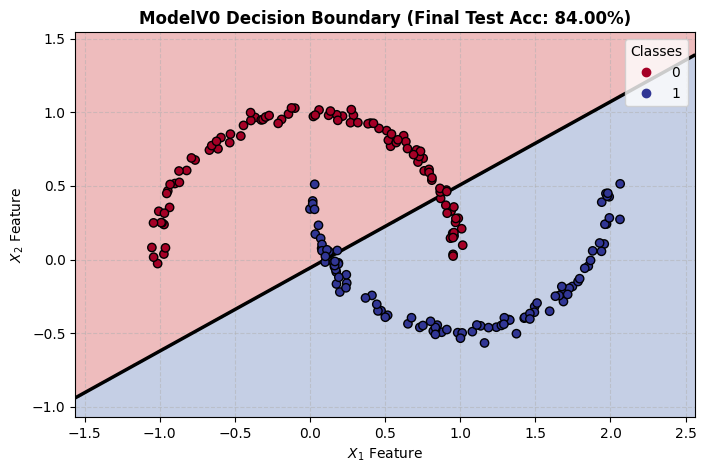

In [353]:
torch.manual_seed(42)
epochs = 100

print("Starting Training for ModelV0...\n" + "-"*50)
for epoch in range(epochs + 1):
    model_v0.train()
    y_logits = model_v0(X_train)
    loss = loss_fn(y_logits, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model_v0.eval()
        with torch.inference_mode():
            test_logits = model_v0(X_test)
            test_loss = loss_fn(test_logits, y_test)
            train_preds = torch.round(torch.sigmoid(y_logits))
            test_preds = torch.round(torch.sigmoid(test_logits))
            train_acc = (train_preds == y_train).sum().item() / len(y_train) * 100
            test_acc = (test_preds == y_test).sum().item() / len(y_test) * 100
            
        print(f"Epoch: {epoch:3d} | Train Loss: {loss.item():.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss.item():.5f}, Test Acc: {test_acc:.2f}%")

# --- PLOTTING  ---
model_v0.eval()
with torch.inference_mode():
    grid_logits = model_v0(grid).reshape(xx.shape).cpu().numpy()
    grid_preds = torch.round(torch.sigmoid(torch.from_numpy(grid_logits))).numpy()

# Generate Plot
plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, grid_preds, cmap=plt.cm.RdYlBu, alpha=0.3)
# Bold visible black line showing the boundary split
plt.contour(xx, yy, grid_logits, levels=[0], colors='black', linewidths=2.5)
scatter = plt.scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu().squeeze(), cmap=plt.cm.RdYlBu, edgecolors='k', zorder=3)

plt.title(f"ModelV0 Decision Boundary (Final Test Acc: {test_acc:.2f}%)", fontsize=12, fontweight='bold')
plt.xlabel("$X_1$ Feature")
plt.ylabel("$X_2$ Feature")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### ModelV0 

ModelV0 which uses layers as discussed earlier improves test accuracy to 84.00% from 73.50% (produced  by purely linear Regression model ie, LinearRegressionNN). But despite the supposed increased accuracy, the prediction graph shows that the cresent moons are being cut and not clearly separated leading to wrong prediction.

#### Mathematically

$$
z = W_2(W_1x + b_1) + b_2 = \underbrace{(W_2W_1)}_{W'}x + \underbrace{(W_2b_1 + b_2)}_{b'}
$$

Two linear layers chained directly together collapse algebraically into one ($z = W'x + b'$). The extra layer adds more *parameters*, but it can't bend the lines to fit the data.

**Conclusion:** ModelV0 is not suitable for the moons dataset, Mathematically it collapses back into a linear model which was the same as LinearRegressionNN with slightly better accuracy. Regardless ModelV0 failed spectacularly too.

### How to Increase Model Accuracy?
The standard techniques for addressing underfitting are:

| Technique | Effect |
| --- | --- |
| **Increasing number of layers** | Increases depth  |
| **Increasing number of hidden units** | Increases width  |
| **Increasing number of epochs** | Gives the optimizer more steps to converge |

Adding more layers could theoretically allow our model to learn more hierarchical complex patterns. Adding hidden units gives each of the layers more size to represent data and increasing epochs will train our podel for longer hopefully allowing it to converge.

These are **hyperparameters** which are chosen before training and not learned or optimized from data.

To test whether depth and width can fix the underfitting problem, `ModelV1` makes three changes: 
* Extra layer (2 → 3 linear layers), 
* Increases hidden units (5 → 10), 
* Trains longer (100 → 1000 epochs).

#### Comparision between ModelV0 and ModelV1
| Change | ModelV0 | ModelV1 |
| --- | --- | --- |
| Number of layers | 2 | 3 |
| Hidden units | 5 | 10 |
| Epochs | 100 | 1000 |

In [354]:
import numpy as np
print("logits range:", grid_logits.min(), grid_logits.max())
print("any NaN/Inf:", np.isnan(grid_logits).any(), np.isinf(grid_logits).any())
print("pred classes seen:", np.unique(grid_preds))

logits range: -6.5399437 6.4875207
any NaN/Inf: False False
pred classes seen: [0. 1.]


Starting Training for ModelV1...
--------------------------------------------------
Epoch:    0 | Train Loss: 0.71976, Acc: 30.75% | Test Loss: 0.70134, Test Acc: 45.50%
Epoch:  200 | Train Loss: 0.24050, Acc: 88.62% | Test Loss: 0.24042, Test Acc: 89.50%
Epoch:  400 | Train Loss: 0.23940, Acc: 88.88% | Test Loss: 0.23715, Test Acc: 89.50%
Epoch:  600 | Train Loss: 0.23940, Acc: 88.88% | Test Loss: 0.23706, Test Acc: 89.00%
Epoch:  800 | Train Loss: 0.23940, Acc: 88.88% | Test Loss: 0.23705, Test Acc: 89.00%
Epoch: 1000 | Train Loss: 0.23940, Acc: 88.88% | Test Loss: 0.23705, Test Acc: 89.00%


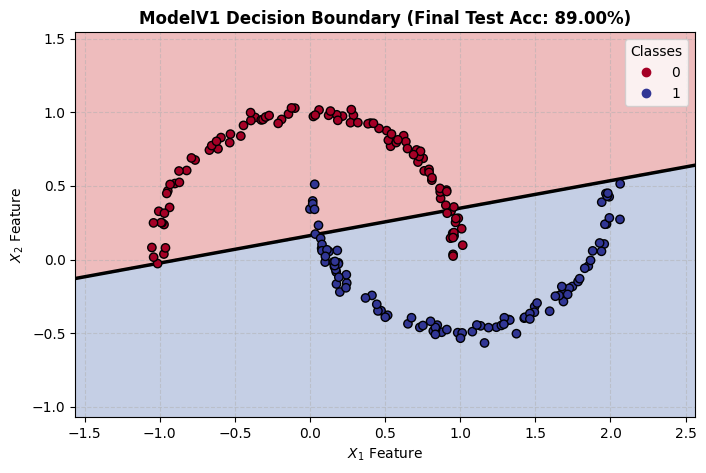

In [355]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_v1 = ModelV1().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_v1.parameters(), lr=0.1)

torch.manual_seed(42)
epochs = 1000

print("Starting Training for ModelV1...\n" + "-"*50)
for epoch in range(epochs + 1):
    model_v1.train()
    y_logits = model_v1(X_train)
    loss = loss_fn(y_logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        model_v1.eval()
        with torch.inference_mode():
            test_logits = model_v1(X_test)
            test_loss = loss_fn(test_logits, y_test)
            train_preds = torch.round(torch.sigmoid(y_logits))
            test_preds = torch.round(torch.sigmoid(test_logits))
            train_acc = (train_preds == y_train).sum().item() / len(y_train) * 100
            test_acc = (test_preds == y_test).sum().item() / len(y_test) * 100

        print(f"Epoch: {epoch:4d} | Train Loss: {loss.item():.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss.item():.5f}, Test Acc: {test_acc:.2f}%")

# Reuse your existing xx, yy grid
model_v1.eval()
with torch.inference_mode():
    grid_logits = model_v1(grid).reshape(xx.shape).cpu().numpy()
    grid_preds = torch.round(torch.sigmoid(torch.from_numpy(grid_logits))).numpy()

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, grid_preds, cmap=plt.cm.RdYlBu, alpha=0.3)
plt.contour(xx, yy, grid_logits, levels=[0], colors='black', linewidths=2.5)
scatter = plt.scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu().squeeze(), cmap=plt.cm.RdYlBu, edgecolors='k', zorder=3)
plt.title(f"ModelV1 Decision Boundary (Final Test Acc: {test_acc:.2f}%)", fontsize=12, fontweight='bold')
plt.xlabel("$X_1$ Feature")
plt.ylabel("$X_2$ Feature")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Here, the accuracy has improved to 89% but the line is still underfit. Furthermore if we look at the output grpah of the predictions, our model clearly still can't separate the moons and is using a single straight line to cut parts of the moons.

## Conclusion:

### Comparision table for ModelV0 and ModelV1

| Change | ModelV0 | ModelV1 |
| --- | --- | --- |
| Hidden units | 5 | 10 |
| Number of layers | 2 (`layer_1`, `layer_2`) | 3 (`layer_1`, `layer_2`, `layer_3`) |
| Epochs | 100 | 1000 |
| Activation function | None | None |

**Result:** Final Test Acc: **89%** (vs. 84.00% for ModelV0)

### Result: Underfitting

Despite more hidden units, an extra layer, and 10x more training, ModelV1's decision boundary is still a straight line. Accuracy may have improved slightly but the graph shows that this clearly coudn't improve the model.

### Why did it fail?

The forward pass is three `nn.Linear` layers chained directly together with nothing in between:

$$
z_1 = W_1x + b_1
$$
$$
z_2 = W_2z_1 + b_2 = (W_2W_1)x + (W_2b_1 + b_2)
$$
$$
z_3 = W_3z_2 + b_3 = (W_3W_2W_1)x + (W_3W_2b_1 + W_3b_2 + b_3)
$$

Collapsing the constants:

$$
z_3 = W'x + b', \quad \text{where } W' = W_3W_2W_1, \ \ b' = W_3W_2b_1 + W_3b_2 + b_3
$$

This is the same form as a single linear layer and we came to this very conclusion in modelV0 too. Stacking nn.Linear layers without a non-linear activation function between them cannot change the model's expressive power. We can see that mathematically three layers are equivalent to one if all of them are linear. The decision boundary, defined by $z_3 = 0$ which is still a equation of staraight line (hyperplane). This illustrates that no matter how many units or layers you add or how long you train the model, if there is no non-linear layer in between, the model will still fail for non linear datasets.


## Adding Relu

Starting Training for NonLinearModel...
--------------------------------------------------
Epoch:    0 | Train Loss: 0.64053, Acc: 72.75% | Test Loss: 0.63365, Test Acc: 71.00%
Epoch:  100 | Train Loss: 0.19883, Acc: 91.00% | Test Loss: 0.20386, Test Acc: 90.50%
Epoch:  200 | Train Loss: 0.09373, Acc: 97.38% | Test Loss: 0.09158, Test Acc: 98.00%
Epoch:  300 | Train Loss: 0.02445, Acc: 100.00% | Test Loss: 0.02258, Test Acc: 100.00%
Epoch:  400 | Train Loss: 0.01040, Acc: 100.00% | Test Loss: 0.00953, Test Acc: 100.00%
Epoch:  500 | Train Loss: 0.00588, Acc: 100.00% | Test Loss: 0.00537, Test Acc: 100.00%


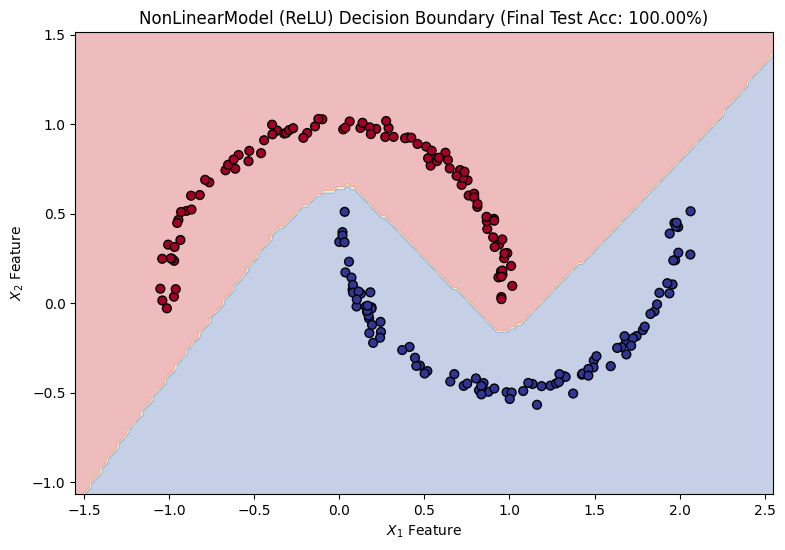

In [356]:
import torch
import torch.nn as nn
import torch.optim as optim

class NonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=16)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(in_features=16, out_features=1)

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        return x

model = NonLinearModel().to(device)   # FIX 1: move model to same device as data

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

torch.manual_seed(42)
epochs = 500

print("Starting Training for NonLinearModel...\n" + "-"*50)
for epoch in range(epochs + 1):
    model.train()
    y_logits = model(X_train)
    loss = loss_fn(y_logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, y_test)
            train_preds = torch.round(torch.sigmoid(y_logits))
            test_preds = torch.round(torch.sigmoid(test_logits))
            train_acc = (train_preds == y_train).sum().item() / len(y_train) * 100
            test_acc = (test_preds == y_test).sum().item() / len(y_test) * 100
        print(f"Epoch: {epoch:4d} | Train Loss: {loss.item():.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss.item():.5f}, Test Acc: {test_acc:.2f}%")


import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                          np.arange(y_min, y_max, 0.02))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.from_numpy(grid_points).float().to(device)  # FIX 2: grid must match model's device

    model.eval()
    with torch.inference_mode():
        logits = model(grid_tensor)
        probs = torch.sigmoid(logits)
        preds = torch.round(probs).cpu().numpy()  # FIX 3: .cpu() before .numpy()

    zz = preds.reshape(xx.shape)
    plt.contourf(xx, yy, zz, cmap=plt.cm.RdYlBu, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, edgecolors='k', s=40)
    plt.xlabel("$X_1$ Feature")
    plt.ylabel("$X_2$ Feature")
    plt.title(f"NonLinearModel (ReLU) Decision Boundary (Final Test Acc: {test_acc:.2f}%)")

X_numpy = X_test.cpu().numpy()   # FIX 3 (same issue here)
y_numpy = y_test.cpu().numpy()

plt.figure(figsize=(9, 6))
plot_decision_boundary(model, X_numpy, y_numpy)
plt.show()

In [357]:
import torch.optim as optim

# 1. Setup Loss and Optimizer
# We use BCEWithLogitsLoss because our model outputs raw logits (numerically stable)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# --- Assuming you already have your data split into tensors: ---
# X_train, y_train, X_test, y_test (Shapes: X is [N, 2], y is [N, 1])

# 2. Simple Training Loop (Example: 500 epochs)
epochs = 500
for epoch in range(epochs):
    model.train()
    
    # Forward Pass: Get raw logits from the model
    y_logits = model(X_train)
    
    # Calculate the Loss
    loss = loss_fn(y_logits, y_train)
    
    # Backward Pass (Optimize parameters)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 3. Evaluation & Making Prediction Outputs
model.eval()
with torch.inference_mode():
    # Get raw logits from the test set
    test_logits = model(X_test)
    
    # Step A: Convert raw logits to probabilities using Sigmoid
    # Values will be squashed tightly between 0.0 and 1.0
    test_probs = torch.sigmoid(test_logits)
    
    # Step B: Convert probabilities to crisp binary predictions (0 or 1)
    # If prob >= 0.5 -> Class 1, else -> Class 0
    test_preds = torch.round(test_probs)

# Print a preview of your binary class predictions
print("Prediction Outputs (First 5):")
print(test_preds[:5])

Prediction Outputs (First 5):
tensor([[1.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')


Starting Training for NonLinearModel...
--------------------------------------------------
Epoch:    0 | Train Loss: 0.64053, Acc: 72.75% | Test Loss: 0.63365, Test Acc: 71.00%
Epoch:  100 | Train Loss: 0.19883, Acc: 91.00% | Test Loss: 0.20386, Test Acc: 90.50%
Epoch:  200 | Train Loss: 0.09373, Acc: 97.38% | Test Loss: 0.09158, Test Acc: 98.00%
Epoch:  300 | Train Loss: 0.02445, Acc: 100.00% | Test Loss: 0.02258, Test Acc: 100.00%
Epoch:  400 | Train Loss: 0.01040, Acc: 100.00% | Test Loss: 0.00953, Test Acc: 100.00%
Epoch:  500 | Train Loss: 0.00588, Acc: 100.00% | Test Loss: 0.00537, Test Acc: 100.00%


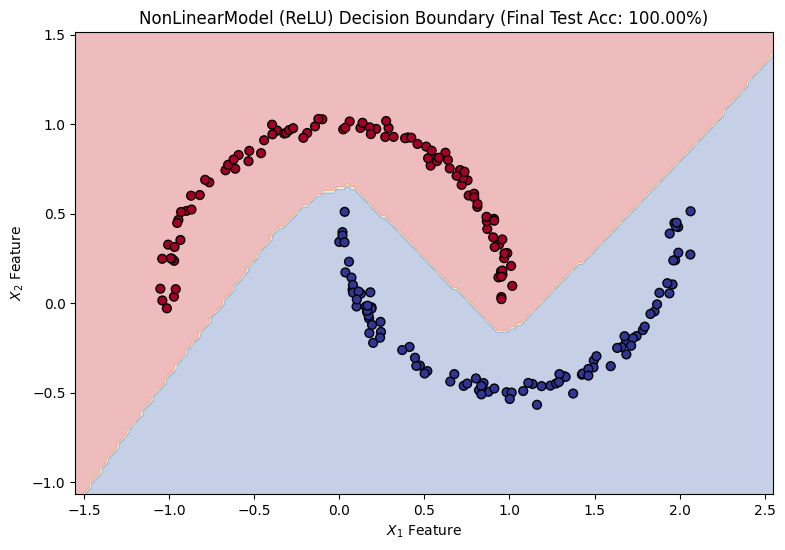

In [358]:
import torch
import torch.nn as nn
import torch.optim as optim

class NonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=16)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(in_features=16, out_features=1)

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        return x

model = NonLinearModel().to(device)   

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

torch.manual_seed(42)
epochs = 500

print("Starting Training for NonLinearModel...\n" + "-"*50)
for epoch in range(epochs + 1):
    model.train()
    y_logits = model(X_train)
    loss = loss_fn(y_logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, y_test)
            train_preds = torch.round(torch.sigmoid(y_logits))
            test_preds = torch.round(torch.sigmoid(test_logits))
            train_acc = (train_preds == y_train).sum().item() / len(y_train) * 100
            test_acc = (test_preds == y_test).sum().item() / len(y_test) * 100
        print(f"Epoch: {epoch:4d} | Train Loss: {loss.item():.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss.item():.5f}, Test Acc: {test_acc:.2f}%")


import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                          np.arange(y_min, y_max, 0.02))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.from_numpy(grid_points).float().to(device)  

    model.eval()
    with torch.inference_mode():
        logits = model(grid_tensor)
        probs = torch.sigmoid(logits)
        preds = torch.round(probs).cpu().numpy()  

    zz = preds.reshape(xx.shape)
    plt.contourf(xx, yy, zz, cmap=plt.cm.RdYlBu, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, edgecolors='k', s=40)
    plt.xlabel("$X_1$ Feature")
    plt.ylabel("$X_2$ Feature")
    plt.title(f"NonLinearModel (ReLU) Decision Boundary (Final Test Acc: {test_acc:.2f}%)")

X_numpy = X_test.cpu().numpy()   
y_numpy = y_test.cpu().numpy()

plt.figure(figsize=(9, 6))
plot_decision_boundary(model, X_numpy, y_numpy)
plt.show()

### Comparision Between all the outputs 

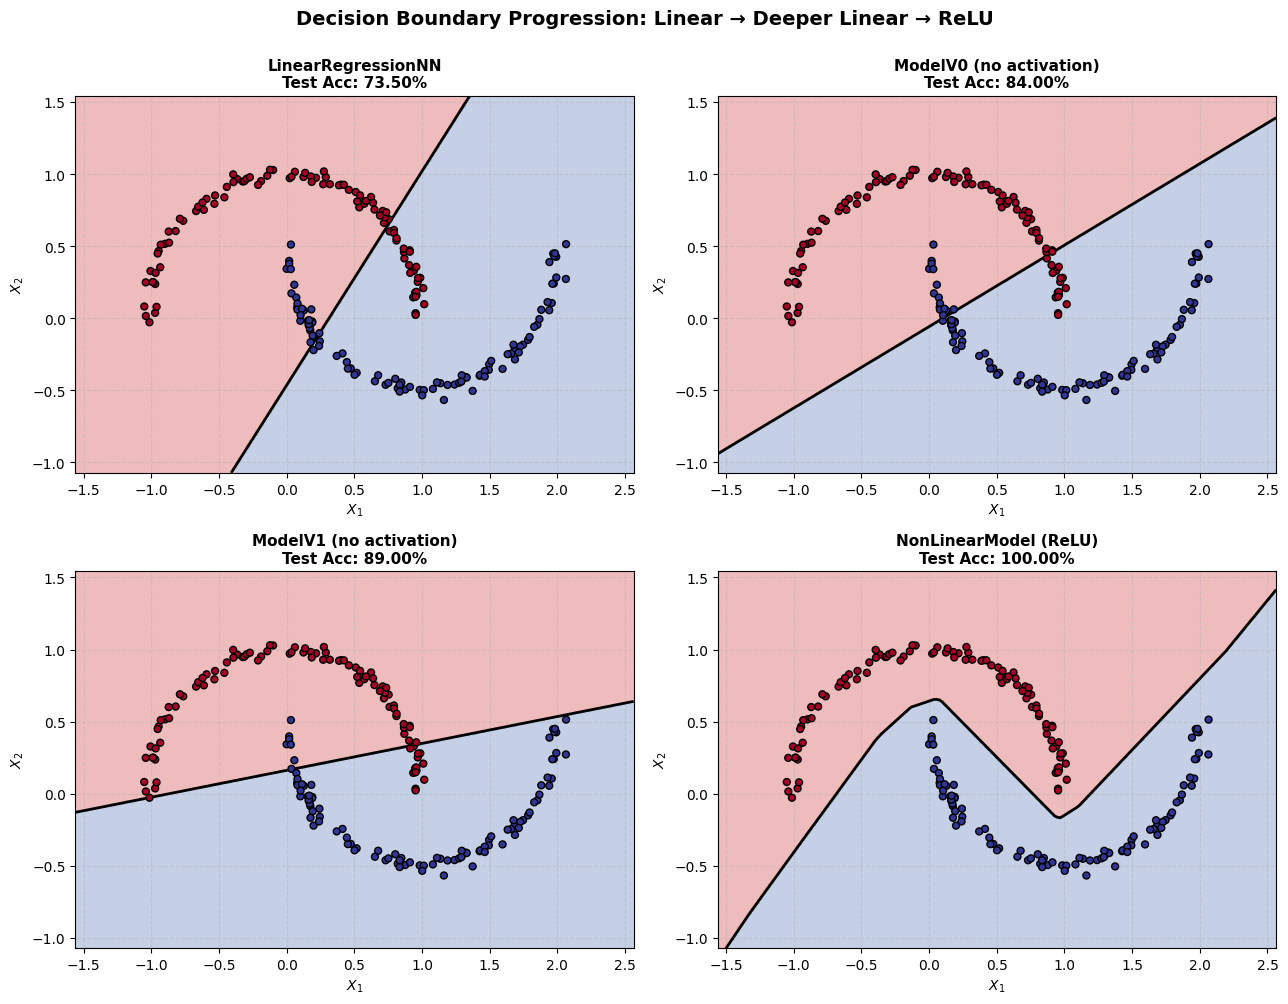

In [359]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def test_accuracy(model, X_test, y_test):
    model.eval()
    with torch.inference_mode():
        preds = torch.round(torch.sigmoid(model(X_test)))
    return (preds == y_test).sum().item() / len(y_test) * 100

# One shared grid so every model is plotted on the exact same coordinates
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).type(torch.float).to(device)

# Rename your ReLU model's variable if needed — assuming model_relu here
models = {
    "LinearRegressionNN":   model_linear,
    "ModelV0 (no activation)": model_v0,
    "ModelV1 (no activation)": model_v1,
    "NonLinearModel (ReLU)": model,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, (name, m) in zip(axes, models.items()):
    m.eval()
    with torch.inference_mode():
        logits_t = m(grid)
        preds_t = torch.round(torch.sigmoid(logits_t))
        logits = logits_t.reshape(xx.shape).cpu().numpy()
        preds = preds_t.reshape(xx.shape).cpu().numpy()

    acc = test_accuracy(m, X_test, y_test)

    ax.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.3)
    ax.contour(xx, yy, logits, levels=[0], colors='black', linewidths=2)
    ax.scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu().squeeze(),
               cmap=plt.cm.RdYlBu, edgecolors='k', s=25, zorder=3)
    ax.set_title(f"{name}\nTest Acc: {acc:.2f}%", fontsize=11, fontweight='bold')
    ax.set_xlabel("$X_1$")
    ax.set_ylabel("$X_2$")
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Decision Boundary Progression: Linear → Deeper Linear → ReLU",
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## Final Conclusion: Why Non-Linearity was the key?

| Model | Layers | Activation | Test Acc | Decision Boundary |
| --- | --- | --- | --- | --- |
| `LinearRegressionNN` | 1 | None | 73.50% | Straight line |
| `ModelV0` | 2 | None | 84.00% | Straight line |
| `ModelV1` | 3 (wider, longer training) | None | 89% | Straight line |
| `NonLinearModel` | 2 | **ReLU** | 100% | Curved, follows the crescents |

Across the first three models, test accuracy slowly improved but the decision boundary curve could never perfectly split the two moons. After attemting to improve the model by increasing layers, hidden units and epochs, ModelV1 still failed. The reason behind the failure of the models were demonstrated mathematically which showed that the added linear layers contributed nothing when it comes to non-linearity because they would collapse back into a linear equation.

NonLinearModel changes this by addidng a ReLu() function which was inserted btween layer1 and layer 2. The introduction of ReLU ($\max(0, x)$) which is a piecewise function we could zero out part of each hidden unit's output. This breaks the algebraic collapse that flattened every previous model back into a linear equation ie, single $z = W'x + b'$. The network can now combine linear pieces into a curved decision boundary. This can be seen on the output graph. 
